# Figure: MPRA DREAM-Challenge benchmark

This figure benchmarks Shorkie against the Gosai/de Boer DREAM-Challenge yeast MPRA. For each held-out test sequence type (yeast / high-expression / low-expression / challenging / random), Shorkie scores every promoter insert with **logSED** (a gene-body variant-effect readout), averaged over output tracks and over the panel of insertion-context positions and the +/- strand reporter genes. The averaged predicted score is plotted against the experimentally measured average expression (MAUDE-estimated YFP fluorescence), with a linear regression line and Pearson/Spearman correlations annotating how well Shorkie recovers the MPRA expression ranking.

**Reproduces:** Predicted-vs-observed scatter + regression for the MPRA expression benchmark (the aggregated panel produced by the source script's `analyze_and_plot_group` / `plot_scatter_with_regression`). The companion high-vs-low classifier ROC/PR analysis lives in `scripts/04_analysis/shorkie/mpra/4_mpra_high_low_seq/5_MPRA_classifier_avg.py` and uses the same NPZ artifacts.

**Upstream:** the per-context logSED NPZ files are produced by `scripts/04_analysis/shorkie/mpra/2_hound_mpra_run/eval_MPRA_h5_logSED.py` (Shorkie ensemble scoring of MPRA inserts into HDF5) followed by `scripts/04_analysis/shorkie/mpra/3_process_hdf5_logsed/` (HDF5 -> per-gene/per-context NPZ), written under `results.mpra_viz`. Run those first; this notebook only loads + plots.

**Requires:** `yeast_ml` conda env + `pip install -e .` (from the repo root). No GPU needed for this notebook (scoring upstream needs GPU). The unreleased NPZ intermediates and the MPRA ground-truth files must be present, so this notebook is **not** runnable end-to-end from released data.

**Source script:** `scripts/04_analysis/shorkie/mpra/5_mpra_viz/MPRA_scatter_regression_single.py` (classifier reference: `scripts/04_analysis/shorkie/mpra/4_mpra_high_low_seq/5_MPRA_classifier_avg.py`).

In [1]:
import os
import re
import csv
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

from shorkie import config

In [2]:
# Path resolution via shorkie.config -- never hardcode absolute paths.
# results.mpra_viz  : per-context logSED NPZ intermediates (UNRELEASED; produced upstream).
# datasets.mpra     : MPRA ground-truth expression + per-seq-type row-index CSVs.
MPRA_VIZ_DIR = config.path('results.mpra_viz')          # .../single_measurement_stranded
MPRA_DATA_DIR = config.path('datasets.mpra')            # .../data/MPRA

SEQ_TYPES_DIR = MPRA_VIZ_DIR / 'results'   # fold-averaged per-context NPZ tree
GT_FILE = MPRA_DATA_DIR / 'filtered_test_data_with_MAUDE_expression.txt'
SUBSET_DIR = MPRA_DATA_DIR / 'test_subset_ids'

print('logSED NPZ root :', SEQ_TYPES_DIR)
print('ground truth    :', GT_FILE)
print('subset id CSVs  :', SUBSET_DIR)

logSED NPZ root : /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/experiments/SUM_data_process/MPRA/MPRA_promoter_seqs/scores_avg/results
ground truth    : /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/data/MPRA/filtered_test_data_with_MAUDE_expression.txt
subset id CSVs  : /home/kchao10/scr4_ssalzbe1/khchao/Yeast_ML/data/MPRA/test_subset_ids


In [3]:
# 1. Load ground-truth expression (tab-separated: sequence \t expression).
with open(GT_FILE) as f:
    lines = list(csv.reader(f, delimiter='\t'))
GROUND_TRUTH_EXP = np.array([float(line[1]) for line in lines])
print('total ground-truth sequences:', len(GROUND_TRUTH_EXP))
print('NaNs:', int(np.sum(np.isnan(GROUND_TRUTH_EXP))),
      '| min:', np.nanmin(GROUND_TRUTH_EXP), '| max:', np.nanmax(GROUND_TRUTH_EXP))

# Per-seq-type row indices into the ground-truth array (CSV 'pos' column).
seq_types = ['yeast_seqs', 'high_exp_seqs', 'low_exp_seqs', 'challenging_seqs', 'all_random_seqs']
csv_indices = {st: pd.read_csv(SUBSET_DIR / f'{st}.csv')['pos'].values for st in seq_types}
for st in seq_types:
    print(f'{st:18s} -> {len(csv_indices[st])} sequences')

total ground-truth sequences: 71103
NaNs: 0 | min: -1.40175772469441 | max: 1.65983547290171
yeast_seqs         -> 964 sequences
high_exp_seqs      -> 968 sequences
low_exp_seqs       -> 997 sequences
challenging_seqs   -> 1981 sequences
all_random_seqs    -> 6349 sequences


In [4]:
# 2. Reporter-gene panel: symbol -> ORF, split by strand (from the source script).
pos_genes = {'GPM3': 'YOL056W', 'SLI1': 'YGR212W', 'VPS52': 'YDR484W', 'YMR160W': 'YMR160W',
             'MRPS28': 'YDR337W', 'YCT1': 'YLL055W', 'RDL2': 'YOR286W', 'PHS1': 'YJL097W',
             'RTC3': 'YHR087W', 'MSN4': 'YKL062W'}
neg_genes = {'COA4': 'YLR218C', 'ERI1': 'YPL096C-A', 'RSM25': 'YIL093C', 'ERD1': 'YDR414C',
             'MRM2': 'YGL136C', 'SNT2': 'YGL131C', 'CSI2': 'YOL007C', 'RPE1': 'YJL121C',
             'PKC1': 'YBL105C', 'AIM11': 'YER093C-A', 'MAE1': 'YKL029C', 'MRPL1': 'YDR116C'}


def context_position(fname):
    """insertion_position = 100 + index*10, parsed from '_context_<index>_'."""
    m = re.search(r'_context_(\d+)_', os.path.basename(fname))
    return 100 + int(m.group(1)) * 10 if m else 0


def gene_avg_scores(seq_type, symbol, orf, strand):
    """Per-sequence predicted score for one reporter gene = mean over tracks
    of logSED, averaged across all insertion-context NPZ files. Returns None if
    no NPZ files exist for this gene/seq_type."""
    gene_dir = SEQ_TYPES_DIR / seq_type / f'{symbol}_{orf}_avg_outputs'  # fold-averaged outputs
    files = sorted(glob.glob(str(gene_dir / f'{orf}_context_*.npz')), key=context_position)
    if not files:
        return None
    per_context = [np.mean(np.load(fp)['logSED'], axis=1) for fp in files]  # each (n_seq,)
    return np.mean(np.stack(per_context, axis=0), axis=0)                   # (n_seq,)

In [5]:
# 3. Aggregate predicted scores across the whole reporter-gene panel for each seq type.
#    For each seq type, average the per-gene predicted-score vectors over every
#    reporter gene that has NPZ output (matching analyze_and_plot_group(..., 'all')).
agg_pred = {}
for seq_type in seq_types:
    gene_vectors = []
    for symbol, orf in pos_genes.items():
        v = gene_avg_scores(seq_type, symbol, orf, 'pos')
        if v is not None:
            gene_vectors.append(v)
    for symbol, orf in neg_genes.items():
        v = gene_avg_scores(seq_type, symbol, orf, 'neg')
        if v is not None:
            gene_vectors.append(v)
    if gene_vectors:
        agg_pred[seq_type] = np.mean(np.stack(gene_vectors, axis=0), axis=0)
        print(f'{seq_type:18s}: aggregated over {len(gene_vectors)} genes, {agg_pred[seq_type].shape[0]} seqs')
    else:
        print(f'{seq_type:18s}: no NPZ output found (run the upstream scoring stage)')

yeast_seqs        : aggregated over 10 genes, 964 seqs


high_exp_seqs     : aggregated over 10 genes, 968 seqs


low_exp_seqs      : aggregated over 10 genes, 997 seqs
challenging_seqs  : no NPZ output found (run the upstream scoring stage)
all_random_seqs   : no NPZ output found (run the upstream scoring stage)


In [6]:
# 4. Build the predicted-vs-observed scatter + regression for the headline
#    representative panel (yeast sequences), faithfully porting plot_scatter_with_regression.
FRIENDLY = {'yeast_seqs': 'Yeast Sequence', 'high_exp_seqs': 'High Expression Sequence',
           'low_exp_seqs': 'Low Expression Sequence', 'challenging_seqs': 'Challenging Sequence',
           'all_random_seqs': 'Random Sequence'}

assert agg_pred, 'No NPZ predictions found for any seq type — run the upstream MPRA scoring stage.'
seq_type = 'yeast_seqs' if 'yeast_seqs' in agg_pred else sorted(agg_pred)[0]   # representative panel
pred = agg_pred[seq_type].astype(np.float64)
gt = GROUND_TRUTH_EXP[csv_indices[seq_type]].astype(np.float64)

mask = np.isfinite(gt) & np.isfinite(pred)
gt, pred = gt[mask], pred[mask]
pearson, _ = pearsonr(gt, pred)
spearman, _ = spearmanr(gt, pred)
print(f'{seq_type}: n={len(gt)}  Pearson={pearson:.3f}  Spearman={spearman:.3f}')

yeast_seqs: n=964  Pearson=0.644  Spearman=0.660


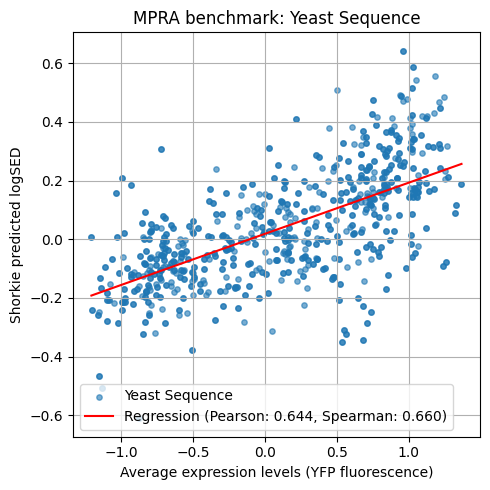

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(gt, pred, label=FRIENDLY[seq_type], s=15, alpha=0.6)

slope, intercept = np.polyfit(gt, pred, 1)
x_reg = np.linspace(gt.min(), gt.max(), 100)
ax.plot(x_reg, slope * x_reg + intercept, 'r-',
        label=f'Regression (Pearson: {pearson:.3f}, Spearman: {spearman:.3f})')

ax.set_xlabel('Average expression levels (YFP fluorescence)')
ax.set_ylabel('Shorkie predicted logSED')
ax.set_title(f'MPRA benchmark: {FRIENDLY[seq_type]}')
ax.legend()
ax.grid(True)
fig.tight_layout()
plt.show()